# Notebook 05 — Comprehensive Model Comparison

**Objective:** Compare three clustering algorithms using intrinsic metrics
and visualizations, then demonstrate the recommendation engine.

**Algorithms compared:**
1. **K-Means** — centroid-based, spherical clusters
2. **DBSCAN** — density-based, arbitrary shapes + noise detection
3. **Hierarchical (Agglomerative)** — tree-based, nested clusters

**Evaluation metrics:**
- Silhouette Score (higher = better)
- Davies-Bouldin Index (lower = better)
- Calinski-Harabasz Index (higher = better)

**Outputs:**
- `outputs/plots/14_dendrogram.png` — hierarchical clustering dendrogram
- `outputs/plots/15_hierarchical_results.png` — hierarchical results
- `outputs/plots/16_final_comparison.png` — all 3 algorithms side-by-side
- `outputs/plots/17_tsne_final.png` — t-SNE comparison of all 3

## 0. Setup & Imports

In [1]:
import os
import sys

NOTEBOOK_DIR = os.path.abspath("")
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Project root : {PROJECT_ROOT}")

Project root : /Users/yugjain/Documents/ML_ASS/unsupervised-professional-matching


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from src.config import (
    RAW_DATA_PATH, PROCESSED_PATH, PLOTS_DIR,
    PCA_COMPONENTS, K_RANGE,
)
from src.models.clustering import (
    run_kmeans_experiment,
    plot_elbow_and_silhouette,
    fit_final_kmeans,
    profile_clusters,
    run_dbscan_experiment,
    plot_dbscan_results,
    fit_final_dbscan,
)
from src.models.hierarchical import (
    run_hierarchical_experiment,
    plot_dendrogram,
    plot_hierarchical_results,
    fit_final_hierarchical,
)
from src.models.compatibility import recommend_profiles
from src.evaluation.intrinsic_metrics import evaluate_clustering, compare_algorithms

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.bbox"] = "tight"
warnings.filterwarnings("ignore")
print("Imports complete")

Imports complete


In [5]:
X = np.load(PROCESSED_PATH)
print(f"Feature matrix shape : {X.shape}")

df_original = pd.read_csv(RAW_DATA_PATH)
print(f"Profiles loaded      : {len(df_original):,}")

vocab_path = os.path.join(PROJECT_ROOT, "data", "processed", "skill_vocab.txt")
with open(vocab_path) as f:
    skill_vocab = [line.strip() for line in f.readlines()]
print(f"Skill vocabulary     : {len(skill_vocab)} terms")

Feature matrix shape : (50000, 188)
Profiles loaded      : 50,000
Skill vocabulary     : 100 terms


## 1. Prepare PCA Space (shared by all algorithms)

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=PCA_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Original dimensions  : {X.shape[1]}")
print(f"PCA dimensions       : {X_pca.shape[1]}")
print(f"Variance retained    : {pca.explained_variance_ratio_.sum()*100:.2f}%")

Original dimensions  : 188
PCA dimensions       : 30
Variance retained    : 31.27%


## 2. K-Means — Centroid-Based Clustering

K-Means partitions data into K clusters by minimizing within-cluster variance.
It assumes clusters are spherical and of similar size.

In [7]:
print(f"Testing K from {K_RANGE.start} to {K_RANGE.stop - 1}...")
kmeans_results = run_kmeans_experiment(X_pca)

Testing K from 2 to 30...
Running K-Means for K = 2 to 30...
  K= 2 | inertia=2,809,892 | silhouette=0.0465
  K= 3 | inertia=2,726,802 | silhouette=0.0471
  K= 4 | inertia=2,655,664 | silhouette=0.0517
  K= 5 | inertia=2,578,948 | silhouette=0.0571
  K= 6 | inertia=2,514,011 | silhouette=0.0632
  K= 7 | inertia=2,448,434 | silhouette=0.0663
  K= 8 | inertia=2,378,436 | silhouette=0.0820
  K= 9 | inertia=2,313,282 | silhouette=0.0871
  K=10 | inertia=2,240,086 | silhouette=0.1020
  K=11 | inertia=2,178,048 | silhouette=0.1092
  K=12 | inertia=2,108,986 | silhouette=0.1157
  K=13 | inertia=2,035,431 | silhouette=0.1284
  K=14 | inertia=1,971,488 | silhouette=0.1369
  K=15 | inertia=1,914,960 | silhouette=0.1449
  K=16 | inertia=1,897,342 | silhouette=0.1343
  K=17 | inertia=1,888,785 | silhouette=0.1194
  K=18 | inertia=1,870,350 | silhouette=0.1120
  K=19 | inertia=1,861,316 | silhouette=0.0919
  K=20 | inertia=1,851,810 | silhouette=0.1006
  K=21 | inertia=1,843,266 | silhouette=0.0859

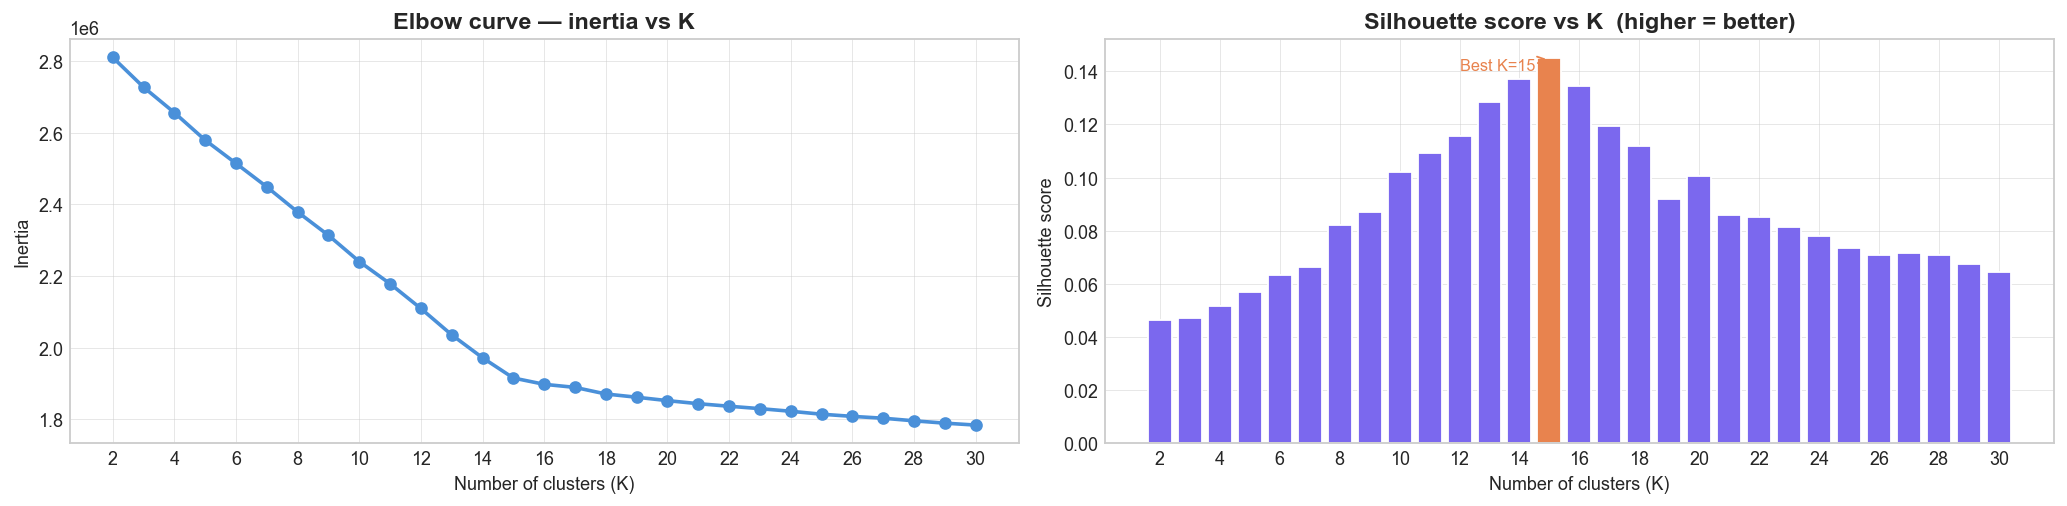


Best K by silhouette score: 15


In [8]:
plot_elbow_and_silhouette(kmeans_results)

In [9]:
BEST_K = int(kmeans_results.loc[kmeans_results["silhouette"].idxmax(), "k"])
print(f"Selected K : {BEST_K}")
print(f"\nFull results table:")
print(kmeans_results.to_string(index=False))

Selected K : 15

Full results table:
 k     inertia  silhouette
 2 2809892.500    0.046480
 3 2726802.000    0.047082
 4 2655663.500    0.051688
 5 2578947.500    0.057131
 6 2514011.250    0.063157
 7 2448434.250    0.066347
 8 2378436.000    0.081976
 9 2313282.500    0.087128
10 2240086.000    0.102003
11 2178047.750    0.109207
12 2108985.500    0.115682
13 2035431.375    0.128415
14 1971487.875    0.136864
15 1914960.000    0.144852
16 1897341.625    0.134297
17 1888785.125    0.119432
18 1870350.000    0.112005
19 1861316.500    0.091927
20 1851810.500    0.100614
21 1843266.000    0.085907
22 1836146.000    0.085122
23 1829463.750    0.081353
24 1822125.500    0.078005
25 1813903.750    0.073530
26 1807829.250    0.070719
27 1802727.000    0.071626
28 1795474.750    0.070747
29 1788940.500    0.067329
30 1783572.250    0.064377


In [10]:
kmeans_labels = fit_final_kmeans(X_pca, BEST_K)

✓ Final K-Means fitted  (K=15)
  Cluster sizes:
    Cluster 0: 3,436 profiles (6.9%)
    Cluster 1: 3,238 profiles (6.5%)
    Cluster 2: 3,269 profiles (6.5%)
    Cluster 3: 3,339 profiles (6.7%)
    Cluster 4: 3,347 profiles (6.7%)
    Cluster 5: 3,301 profiles (6.6%)
    Cluster 6: 3,362 profiles (6.7%)
    Cluster 7: 3,375 profiles (6.8%)
    Cluster 8: 3,326 profiles (6.7%)
    Cluster 9: 3,345 profiles (6.7%)
    Cluster 10: 3,234 profiles (6.5%)
    Cluster 11: 3,355 profiles (6.7%)
    Cluster 12: 3,328 profiles (6.7%)
    Cluster 13: 3,313 profiles (6.6%)
    Cluster 14: 3,432 profiles (6.9%)


In [11]:
kmeans_summary = profile_clusters(kmeans_labels, df_original, skill_vocab)
print("K-Means Cluster summary:")
print(kmeans_summary.to_string(index=False))

K-Means Cluster summary:
 cluster  size  pct_of_total                                                                     top_skills  dominant_industry        dominant_role  median_exp top_seniority
       0  3436           6.9       inventory management, forecasting, statistics, tableau, machine learning             Retail      Product Manager        5.00           mid
       1  3238           6.5                           css, adobe creative suite, html, node.js, javascript              Media          ML Engineer        5.30           mid
       2  3269           6.5         spss, genomics, laboratory techniques, bioinformatics, clinical trials      Biotechnology  Engineering Manager        5.40           mid
       3  3339           6.7                                          sql, kubernetes, git, tensorflow, aws         Technology        Data Engineer        5.20           mid
       4  3347           6.7                             plc, optimization, renewable energy, statistics,

## 3. DBSCAN — Density-Based Clustering

DBSCAN groups points in dense regions and marks outliers as noise.
It can find clusters of arbitrary shape.

In [12]:
dbscan_results = run_dbscan_experiment(
    X_pca,
    eps_values=[0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5, 0.6],
    min_samples_values=[5, 10, 20, 50],
    n_components=8
)

  Reduced to 8 components for DBSCAN (33.0% variance)
Running DBSCAN grid search: 32 combinations...
  [1/32] eps=0.15 min_samples=  5 | clusters= 66 | noise= 98.4% | sil=n/a
  [2/32] eps=0.15 min_samples= 10 | clusters=  4 | noise= 99.9% | sil=n/a
  [3/32] eps=0.15 min_samples= 20 | clusters=  0 | noise=100.0% | sil=n/a
  [4/32] eps=0.15 min_samples= 50 | clusters=  0 | noise=100.0% | sil=n/a
  [5/32] eps=0.20 min_samples=  5 | clusters=366 | noise= 81.3% | sil=-0.1580
  [6/32] eps=0.20 min_samples= 10 | clusters= 46 | noise= 93.3% | sil=n/a
  [7/32] eps=0.20 min_samples= 20 | clusters=  5 | noise= 98.2% | sil=n/a
  [8/32] eps=0.20 min_samples= 50 | clusters=  1 | noise= 99.9% | sil=n/a
  [9/32] eps=0.25 min_samples=  5 | clusters=251 | noise= 42.8% | sil=-0.4913
  [10/32] eps=0.25 min_samples= 10 | clusters= 50 | noise= 65.0% | sil=-0.2555
  [11/32] eps=0.25 min_samples= 20 | clusters= 20 | noise= 84.3% | sil=0.2734
  [12/32] eps=0.25 min_samples= 50 | clusters=  7 | noise= 96.2% | s

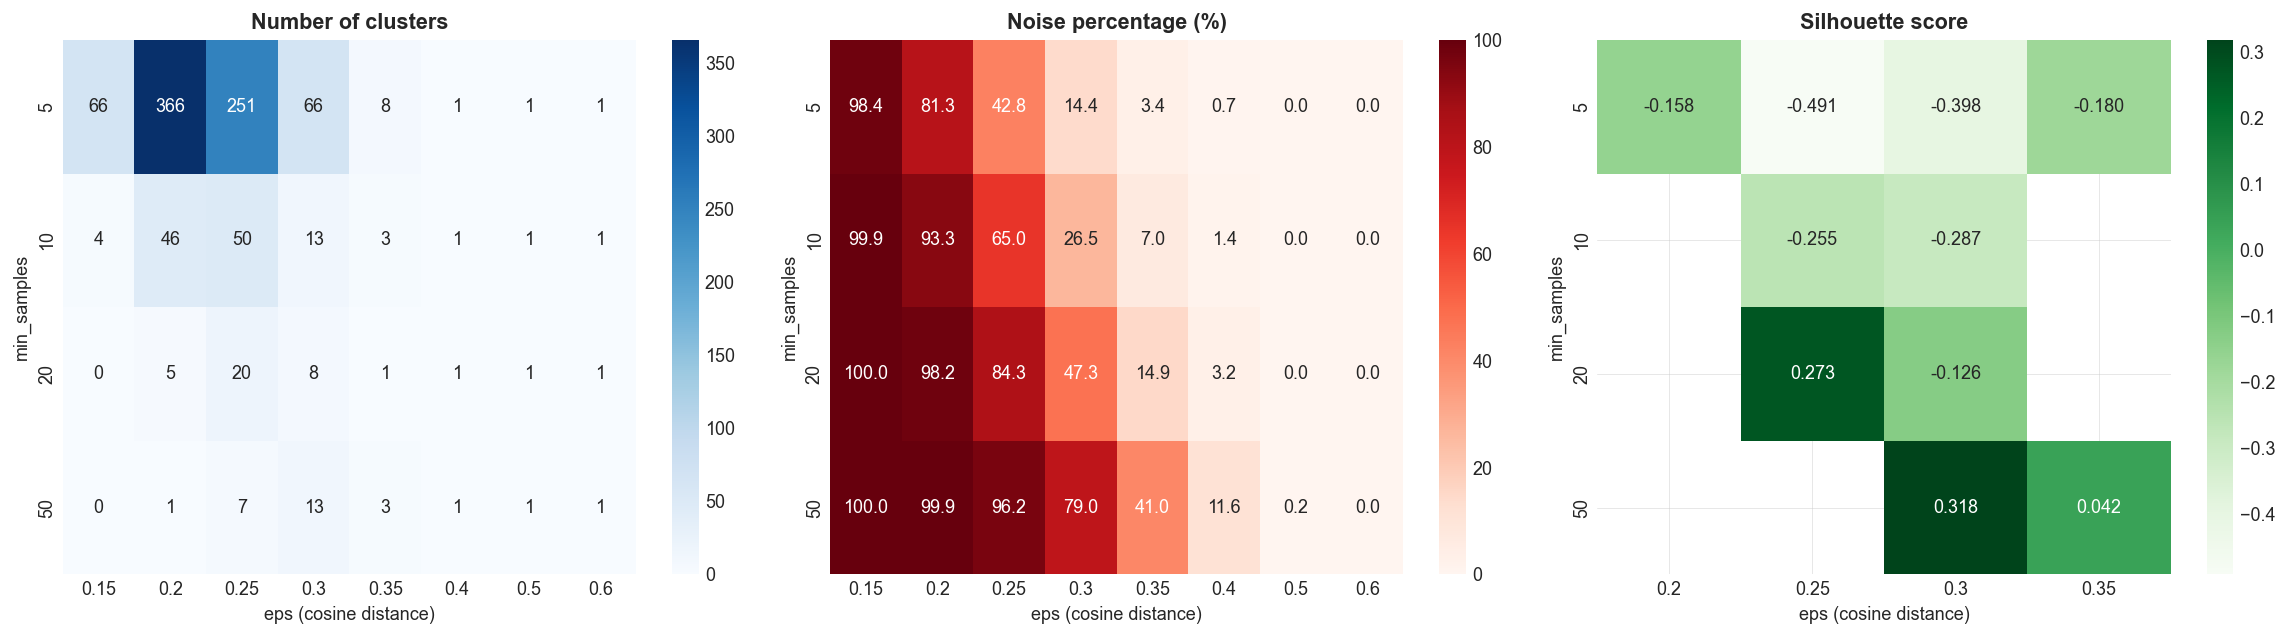


Best DBSCAN by silhouette:
  eps=0.3, min_samples=50.0 | clusters=13 | noise=79.0% | silhouette=0.31779998540878296


In [13]:
plot_dbscan_results(dbscan_results)

In [14]:
best_dbscan = dbscan_results.dropna(subset=["silhouette"])
if len(best_dbscan) > 0:
    best_row = best_dbscan.loc[best_dbscan["silhouette"].idxmax()]
    BEST_EPS = best_row["eps"]
    BEST_MIN_SAMPLES = int(best_row["min_samples"])
    print(f"Best DBSCAN params: eps={BEST_EPS}, min_samples={BEST_MIN_SAMPLES}")
    print(f"  Clusters: {int(best_row['n_clusters'])} | "
          f"Noise: {best_row['noise_pct']}% | "
          f"Silhouette: {best_row['silhouette']}")
else:
    BEST_EPS = 0.3
    BEST_MIN_SAMPLES = 50
    print("Using default DBSCAN params")

Best DBSCAN params: eps=0.3, min_samples=50
  Clusters: 13 | Noise: 79.0% | Silhouette: 0.31779998540878296


In [15]:
dbscan_labels = fit_final_dbscan(X_pca, eps=BEST_EPS, min_samples=BEST_MIN_SAMPLES,
                                 n_components=8)

✓ Final DBSCAN fitted  (eps=0.3, min_samples=50)
  Clusters found : 13
  Noise points   : 39,489 (79.0%)
  Cluster sizes:
    Cluster 0: 2,543 profiles (5.1%)
    Cluster 1: 1,733 profiles (3.5%)
    Cluster 2: 2,886 profiles (5.8%)
    Cluster 3: 771 profiles (1.5%)
    Cluster 4: 1,224 profiles (2.4%)
    Cluster 5: 191 profiles (0.4%)
    Cluster 6: 374 profiles (0.7%)
    Cluster 7: 121 profiles (0.2%)
    Cluster 8: 461 profiles (0.9%)
    Cluster 9: 42 profiles (0.1%)
    Cluster 10: 72 profiles (0.1%)
    Cluster 11: 42 profiles (0.1%)
    Cluster 12: 51 profiles (0.1%)


In [16]:
dbscan_summary = profile_clusters(dbscan_labels, df_original, skill_vocab)
print("DBSCAN Cluster summary:")
print(dbscan_summary.to_string(index=False))

DBSCAN Cluster summary:
 cluster  size  pct_of_total                                                            top_skills  dominant_industry        dominant_role  median_exp top_seniority
      -1 39489          79.0                    python, sql, statistics, machine learning, tableau          Aerospace Full Stack Developer        5.40           mid
       0  2543           5.1 e-learning, instructional design, curriculum development, lms, moodle          Education    Software Engineer        5.10           mid
       1  1733           3.5       seo, content strategy, css, video editing, adobe creative suite              Media       Technical Lead        4.90           mid
       2  2886           5.8                                   docker, kubernetes, java, cicd, api Telecommunications          ML Engineer        4.70         entry
       3   771           1.5                   plc, lean manufacturing, iot, six sigma, automation      Manufacturing          ML Engineer        2.80 

## 4. Hierarchical Clustering (Agglomerative)

Agglomerative clustering builds a tree of clusters by merging the closest
pairs iteratively. Three linkage methods are tested:

| Linkage | How it works | Best for |
|---|---|---|
| Ward | Minimizes within-cluster variance | Spherical clusters (like K-Means) |
| Complete | Max distance between clusters | Compact, well-separated clusters |
| Average | Average distance between clusters | Balanced approach |

In [ ]:
hc_results = run_hierarchical_experiment(
    X_pca,
    n_clusters_range=[3, 5, 8, 10, 12, 15, 20],
    linkage_methods=["ward", "complete", "average"]
)

Running Hierarchical Clustering: 21 combinations...


In [ ]:
plot_hierarchical_results(hc_results)

In [ ]:
valid_hc = hc_results.dropna(subset=["silhouette"])
if len(valid_hc) > 0:
    best_hc = valid_hc.loc[valid_hc["silhouette"].idxmax()]
    BEST_HC_K = int(best_hc["n_clusters"])
    BEST_HC_LINKAGE = best_hc["linkage"]
    print(f"Best Hierarchical: n={BEST_HC_K}, linkage={BEST_HC_LINKAGE} | "
          f"silhouette={best_hc['silhouette']}")
else:
    BEST_HC_K = BEST_K
    BEST_HC_LINKAGE = "ward"
    print("Using default hierarchical params")

In [ ]:
hc_labels = fit_final_hierarchical(X_pca, n_clusters=BEST_HC_K,
                                   linkage_method=BEST_HC_LINKAGE)

In [ ]:
plot_dendrogram(X_pca, n_clusters=BEST_HC_K)

In [ ]:
hc_summary = profile_clusters(hc_labels, df_original, skill_vocab)
print("Hierarchical Cluster summary:")
print(hc_summary.to_string(index=False))

## 5. Algorithm Comparison — All Three

All algorithms are evaluated using the same three intrinsic metrics:

| Metric | What it measures | Better when |
|---|---|---|
| Silhouette Score | Cohesion vs separation | Higher (max 1.0) |
| Davies-Bouldin Index | Average cluster similarity | Lower (min 0.0) |
| Calinski-Harabasz Index | Between/within cluster variance ratio | Higher |

In [ ]:
kmeans_metrics = evaluate_clustering(X_pca, kmeans_labels)
dbscan_metrics = evaluate_clustering(X_pca, dbscan_labels)
hc_metrics = evaluate_clustering(X_pca, hc_labels)

comparison_df = compare_algorithms({
    "K-Means": kmeans_metrics,
    "DBSCAN": dbscan_metrics,
    "Hierarchical": hc_metrics,
})

print("=" * 80)
print("ALGORITHM COMPARISON")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("=" * 80)

In [ ]:
metrics_to_plot = ["silhouette", "davies_bouldin", "calinski_harabasz"]
metrics_labels = [
    "Silhouette Score\n(higher = better)",
    "Davies-Bouldin Index\n(lower = better)",
    "Calinski-Harabasz Index\n(higher = better)"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
algo_colors = {"K-Means": "#4A90D9", "DBSCAN": "#E8834E", "Hierarchical": "#7B68EE"}

for i, (metric, label) in enumerate(zip(metrics_to_plot, metrics_labels)):
    values = comparison_df[metric].values
    algos = comparison_df["algorithm"].values
    colors = [algo_colors.get(a, "#999999") for a in algos]
    
    bars = axes[i].bar(algos, values, color=colors, edgecolor="white", width=0.5)
    
    for bar, val in zip(bars, values):
        if not np.isnan(val) and val is not None:
            axes[i].text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + (max(np.nan_to_num(values))*0.02 if max(np.nan_to_num(values)) > 0 else 0.01),
                f"{val:.4f}" if metric != "calinski_harabasz" else f"{val:.1f}",
                ha="center", va="bottom", fontsize=10, fontweight="bold"
            )
    axes[i].set_title(label, fontsize=12, fontweight="bold")
    axes[i].set_ylabel(metric.replace("_", " ").title())

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "16_final_comparison.png"))
plt.show()

print("\nComparison plot saved → outputs/plots/16_final_comparison.png")

### 5a. Cluster Size Distribution

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

algo_configs = [
    ("K-Means", kmeans_metrics, kmeans_labels, "#4A90D9"),
    ("DBSCAN", dbscan_metrics, dbscan_labels, "#E8834E"),
    ("Hierarchical", hc_metrics, hc_labels, "#7B68EE"),
]

for ax, (name, metrics, labels, color) in zip(axes, algo_configs):
    clusters = sorted([k for k in metrics["cluster_sizes"].keys() if k != "noise"])
    sizes = [metrics["cluster_sizes"].get(k, 0) for k in clusters]
    
    ax.bar(range(len(sizes)), sizes, color=color, edgecolor="white")
    
    noise_count = metrics["cluster_sizes"].get("noise", 0)
    if noise_count > 0:
        ax.bar(len(sizes), noise_count, color="#999999", edgecolor="white")
        ax.set_xticks(list(range(len(sizes))) + [len(sizes)])
        ax.set_xticklabels([str(k) for k in clusters] + ["Noise"])
    else:
        ax.set_xticks(range(len(sizes)))
        ax.set_xticklabels([str(k) for k in clusters])
    
    ax.set_title(f"{name} (clusters={len(clusters)}, noise={noise_count:,})",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Cluster ID")
    ax.set_ylabel("Number of profiles")

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "17_cluster_sizes.png"))
plt.show()

### 5b. t-SNE Visual Comparison

In [ ]:
print("Running t-SNE for comparison visualisation...")
tsne = TSNE(n_components=2, random_state=42, perplexity=40, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca)
print("t-SNE complete.")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

algo_configs = [
    ("K-Means", kmeans_labels, "#4A90D9"),
    ("DBSCAN", dbscan_labels, "#E8834E"),
    ("Hierarchical", hc_labels, "#7B68EE"),
]

for ax, (name, labels, base_color) in zip(axes, algo_configs):
    unique_clusters = sorted(set(labels) - {-1})
    palette = sns.color_palette("tab10", n_colors=max(len(unique_clusters), 10))
    
    for i, cid in enumerate(unique_clusters):
        mask = labels == cid
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   c=[palette[i % 10]], label=f"C{cid} (n={mask.sum():,})",
                   alpha=0.35, s=3, linewidths=0)
    
    noise_mask = labels == -1
    if noise_mask.sum() > 0:
        ax.scatter(X_tsne[noise_mask, 0], X_tsne[noise_mask, 1],
                   c=["#999999"], label=f"Noise (n={noise_mask.sum():,})",
                   alpha=0.15, s=2, linewidths=0)
    
    ax.set_title(f"{name} clustering (t-SNE)", fontsize=13, fontweight="bold")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(markerscale=3, fontsize=6, loc="upper left")

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "17_tsne_final.png"))
plt.show()

print("t-SNE comparison saved → outputs/plots/17_tsne_final.png")

## 6. Recommendation Demo — Test on a Real Profile

We pick a specific profile and find the 5 most compatible profiles
using the best algorithm's clustering + cosine similarity pipeline.

In [ ]:
best_algo = comparison_df.loc[comparison_df["silhouette"].idxmax(), "algorithm"]
print(f"Best algorithm by silhouette: {best_algo}")

if best_algo == "K-Means":
    best_labels = kmeans_labels
elif best_algo == "DBSCAN":
    best_labels = dbscan_labels
else:
    best_labels = hc_labels

In [ ]:
QUERY_IDX = 42

query = df_original.iloc[QUERY_IDX]
print("=" * 60)
print("QUERY PROFILE")
print("=" * 60)
print(f"Profile ID      : {query['profile_id']}")
print(f"Name            : {query['name']}")
print(f"Role            : {query['current_role']}")
print(f"Company         : {query['current_company']}")
print(f"Industry        : {query['industry']}")
print(f"Seniority       : {query['seniority_level']}")
print(f"Experience      : {query['years_experience']} years")
print(f"Connections     : {query['connections']:,}")
print(f"Location        : {query['location']}")
print(f"Remote pref     : {query['remote_preference']}")
print(f"Skills          : {query['skills']}")
print(f"Goals           : {query['goals']}")
print(f"Needs           : {query['needs']}")
print(f"Can offer       : {query['can_offer']}")
print(f"K-Means Cluster : {int(kmeans_labels[QUERY_IDX])}")
print(f"DBSCAN Cluster  : {int(dbscan_labels[QUERY_IDX])}")
print(f"Hierarchical    : {int(hc_labels[QUERY_IDX])}")

In [ ]:
df_original["cluster"] = best_labels

recommendations = recommend_profiles(
    query_idx   = QUERY_IDX,
    X           = X,
    labels      = best_labels,
    df_original = df_original,
    top_n       = 5
)

print("=" * 60)
print(f"TOP 5 COMPATIBLE PROFILES  ({best_algo} Cluster {int(best_labels[QUERY_IDX])})")
print("=" * 60)

for rank, (_, row) in enumerate(recommendations.iterrows(), start=1):
    print(f"\n{'─' * 60}")
    print(f"Rank {rank}  —  similarity score: {row['similarity_score']:.4f}")
    print(f"  Name        : {row['name']}")
    print(f"  Role        : {row['current_role']}")
    print(f"  Company     : {row['current_company']}")
    print(f"  Industry    : {row['industry']}")
    print(f"  Seniority   : {row['seniority_level']}")
    print(f"  Experience  : {row['years_experience']} years")
    print(f"  Location    : {row['location']}")
    print(f"  Skills      : {row['skills']}")
    print(f"  Goals       : {row['goals']}")
    print(f"  Needs       : {row['needs']}")
    print(f"  Can offer   : {row['can_offer']}")

print(f"\n{'=' * 60}")

## 7. Final Summary

In [ ]:
print("=" * 80)
print("FINAL RESULTS SUMMARY")
print("=" * 80)
print(f"\nDataset            : {len(df_original):,} profiles")
print(f"Features           : {X.shape[1]} (after preprocessing)")
print(f"PCA dimensions     : {X_pca.shape[1]} "
      f"({pca.explained_variance_ratio_.sum()*100:.1f}% variance)")
print(f"\n{'─' * 80}")
print(comparison_df.to_string(index=False))
print(f"{'─' * 80}")

best_algo = comparison_df.loc[comparison_df["silhouette"].idxmax(), "algorithm"]
print(f"\nBest algorithm by silhouette score: {best_algo}")
print(f"\nAll plots saved to: {PLOTS_DIR}")
print(f"All cluster CSVs saved to: {os.path.join(PROJECT_ROOT, 'outputs', 'clusters')}")